<a href="https://colab.research.google.com/github/Riffanjunyffer/Data-Science-2026/blob/main/Pertemuan13_RiffanJunyfferNainggolan_250401020087.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Langkah 1: Generate & Eksplorasi Dataset Non-Linear

Buat dataset make_moons, lalu visualisasikan untuk melihat mengapa data ini tidak bisa dipisahkan garis lurus.

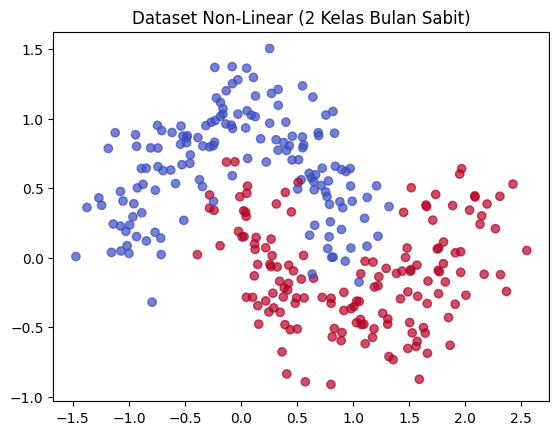

In [17]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

Langkah 2: Bangun & Latih Neural Network Sederhana

Bangun arsitektur neural network dengan activation function ReLU dan Sigmoid, lalu latih modelnya.

In [18]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Langkah 3: Evaluasi & Visualisasi Kurva Belajar

Evaluasi model pada data uji, lalu plot kurva akurasi training vs validasi untuk melihat proses belajarnya.

Akurasi pada data uji: 0.900


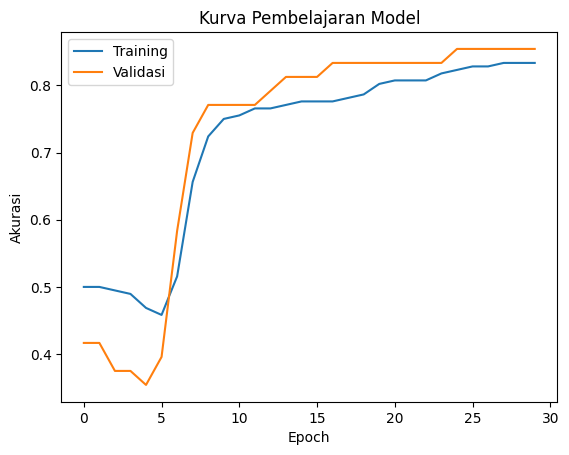

In [19]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

Langkah 4: Siapkan Dataset Ulasan Produk

Buat dataset ulasan produk sederhana
dengan label sentimen positif/negatif.

In [20]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Packing rapi dan aman, terima kasih',
    'Pengiriman super lambat, kurirnya tidak ramah',
    'Fungsinya normal, awet dipakai sehari-hari',
    'Barang palsu, menyesal beli di sini',
    'Harga terjangkau tapi kualitas mewah',
    'Bahan tipis dan mudah robek',
    'Sesuai gambar, ukurannya pas di badan',
    'Warna luntur saat pertama kali dicuci',
    'Admin sangat responsif dan membantu',
    'Garansi susah diklaim, ribet banget pelayanannya',
    'Desain elegan, terlihat sangat premium',
    'Tombolnya macet, produk sepertinya cacat produksi',
    'Mudah digunakan, instruksi manualnya sangat jelas',
    'Baterai cepat habis, boros banget tidak sesuai klaim',
    'Suara audionya jernih, bass-nya mantap',
    'Ukurannya kekecilan, tidak sesuai dengan panduan tabel',
    'Bahan adem dan sangat nyaman dipakai seharian',
    'Pecah belah, packing kurang tebal bubble wrap-nya',
    'Fiturnya sangat lengkap, benar-benar melebihi ekspektasi saya',
    'Kamera buram, resolusinya jelek sekali',
    'Expired date masih lama, sangat aman untuk dikonsumsi',
    'Aromanya aneh, seperti barang yang sudah lama disimpan',
    'Instalasi sangat mudah, colok langsung bisa dipakai',
    'Sistemnya sering error saat baru dinyalakan',
    'Anak saya suka banget sama mainan barunya',
    'Jahitannya tidak rapi, banyak benang yang lepas',
    'Dapat bonus aksesoris juga, tokonya sangat amanah',
    'Respon penjual lambat, di-chat dari pagi baru dibalas malam',
    'Kualitas layar sangat tajam, warnanya memuaskan',
    'Mesin cepat panas padahal baru dipakai beberapa menit',
    'Original 100%, jangan ragu untuk belanja di toko ini',
    'Kabelnya terlalu pendek, susah dicolok kalau stopkontak jauh',
    'Teksturnya lembut di kulit dan wanginya tahan lama',
    'Rasanya kurang pas di lidah, bumbunya terlalu asin'
]

label = [
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0
]

# Pengecekan jumlah data untuk memastikan ulasan dan label seimbang
print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Jumlah label: {len(label)}')

Jumlah ulasan: 40
Jumlah label: 40


Langkah 5: Ubah Teks Menjadi TF-IDF

Ubah seluruh ulasan menjadi representasi TF-IDF, lalu lihat kata-kata dengan skor tertinggi.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 189
['100' 'adem' 'admin' 'akan' 'aksesoris' 'aman' 'amanah' 'anak' 'aneh'
 'aromanya']


Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi

Latih model Logistic Regression sederhana untuk memprediksi sentimen, lalu uji dengan kalimat baru.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.625
Positif
